In [92]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import re
from datetime import datetime
import openpyxl as op
import seaborn as sns

In [93]:
df = pd.read_excel("CleanedCollinandOwenDummy.xlsx", sheet_name=4)

In [94]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,NaN,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,NaN,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,NaN,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,NaN,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00


In [95]:
df = df.iloc[:, 1:]

In [96]:
df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00
...,...,...,...,...,...,...,...,...,...,...
165,126.20,133.44,140.08,134.92,140.28,106.56,121.20,124.48,117.40,123.84
166,127.00,123.56,140.24,139.60,134.56,106.88,121.00,124.44,117.44,123.96
167,127.92,117.04,140.64,142.24,128.04,107.20,120.88,124.36,117.60,124.40
168,127.96,112.08,140.40,142.84,120.32,107.12,120.60,123.44,117.72,124.80


In [97]:
df = df.T

In [98]:
df

,0,1,2,3,4,5,6,7,8,9,...,160,161,162,163,164,165,166,167,168,169
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,127.76,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,172.72,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,138.96,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,102.40,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,142.72,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,106.92,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.88,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.04,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.64,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.16,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04


First 5 columns is Collin, next 5 is Owen

In [99]:
# build the label list
labels = ['Collin']*5 + ['Owen_Dummy']*5

# assign it as a new column
df['label'] = labels

In [100]:
df

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Collin
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Collin
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Collin
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Collin
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Collin
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,Owen_Dummy
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60,Owen_Dummy
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64,Owen_Dummy
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60,Owen_Dummy
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04,Owen_Dummy


Fill NAs with 0

In [101]:
df.fillna(0, inplace=True)

In [102]:
df.isna().sum().sum()

np.int64(0)

# Now we add more cleaned data

In [207]:
connor = pd.read_csv("Math_232_Data/data/ConnorFlood_filtered.csv")
connor = connor.iloc[:, 1:]
connor = connor.drop(index = 8)
connor.columns = list(range(len(connor.columns)))
connor["label"] = "Connor"
connor.head()

,0,1,2,3,4,5,6,7,8,9,...,162,163,164,165,166,167,168,169,170,label
0,280.68,280.64,280.60,280.52,279.96,279.32,279.28,278.44,277.08,275.40,...,200.64,199.72,207.76,220.40,235.92,252.24,265.28,271.28,273.76,Connor
1,274.08,274.40,274.48,274.28,275.00,275.96,276.64,278.80,280.84,282.52,...,252.76,241.96,225.88,214.48,209.72,218.96,232.52,249.36,262.64,Connor
2,274.52,271.84,267.92,263.60,259.72,256.48,255.16,255.52,256.80,258.04,...,225.92,238.28,246.96,248.16,245.52,240.32,233.80,225.80,215.36,Connor
3,220.24,225.92,232.64,240.00,246.16,250.88,252.24,251.52,250.20,248.96,...,215.60,204.04,193.04,184.24,176.96,172.36,169.56,168.16,167.40,Connor
4,276.00,278.12,279.68,280.76,280.64,280.44,278.80,277.68,276.28,275.92,...,271.80,262.72,251.20,233.76,217.60,203.16,191.92,183.24,181.32,Connor


In [ ]:
matthew = pd.read_csv("Math_232_Data/data/MatthewRiley_filtered.csv")
matthew = matthew.iloc[:, 1:171]
# matthew = matthew.drop(index=[1, 7, 8, 9, 10]) # remove weird jumps
matthew.columns = list(range(len(matthew.columns)))
matthew["label"] = "Matthew"
matthew.head()


,0,1,2,3,4,5,6,7,8,9,...,162,163,164,165,166,167,168,169,170,label
0,264.56,263.96,263.24,262.48,261.12,260.32,259.36,258.12,257.08,256.32,...,236.88,246.48,253.20,253.04,249.60,242.48,233.48,223.60,214.04,Matthew
1,259.80,261.24,262.84,264.52,265.80,266.12,267.64,268.56,269.60,270.04,...,171.64,178.44,194.48,212.48,231.04,247.12,255.40,257.88,259.08,Matthew
2,278.28,278.76,278.44,278.16,277.20,276.48,276.28,276.96,278.20,279.72,...,272.88,270.40,266.52,264.12,264.08,267.32,272.16,277.96,282.96,Matthew
3,264.08,267.32,272.16,277.96,282.96,285.80,287.20,287.48,287.36,286.68,...,266.40,266.92,266.76,267.04,266.64,266.36,267.04,268.44,269.44,Matthew
4,258.12,252.56,246.68,240.40,234.68,229.12,224.28,220.04,217.52,216.40,...,265.00,265.36,265.92,266.60,266.96,267.40,267.76,267.88,267.96,Matthew


In [210]:
owen = pd.read_csv("Math_232_Data/data/Owen_filtered.csv")
owen = owen.iloc[:, 1:] # remove weird jumps
owen.columns = list(range(len(owen.columns)))
owen["label"] = "Owen"
owen.head()

,0,1,2,3,4,5,6,7,8,9,...,162,163,164,165,166,167,168,169,170,label
0,286.64,288.80,290.36,290.92,290.00,288.20,286.48,285.28,284.72,284.92,...,324.32,306.84,286.36,262.32,235.36,208.92,197.20,189.20,190.36,Owen
1,286.12,284.80,282.04,276.96,268.64,258.28,246.28,233.64,222.72,216.32,...,236.32,237.64,229.64,216.36,198.44,179.84,163.56,152.48,145.52,Owen
2,240.16,228.56,219.40,216.28,218.28,224.40,236.40,246.12,249.52,247.68,...,126.44,146.00,166.12,183.00,190.72,198.68,208.04,219.00,229.28,Owen
3,254.64,256.76,258.92,259.88,259.84,258.92,257.00,252.24,246.52,239.64,...,288.48,291.32,283.56,268.04,247.88,226.24,204.36,195.68,195.40,Owen
4,226.24,204.36,195.68,195.40,203.08,219.36,242.40,260.00,276.76,289.92,...,222.76,222.00,214.12,205.60,195.20,183.24,170.76,164.64,159.04,Owen


In [211]:
ian = pd.read_csv("Math_232_Data/data/IanLim_filtered.csv")
ian = ian.iloc[:, 1:] # remove weird jumps
ian.columns = list(range(len(ian.columns)))
ian["label"] = "Ian"
ian.head()

,0,1,2,3,4,5,6,7,8,9,...,162,163,164,165,166,167,168,169,170,label
0,271.36,256.32,245.60,243.08,248.68,258.28,271.48,287.72,300.52,309.36,...,319.48,318.60,316.96,315.88,315.12,315.84,318.24,321.00,322.88,Ian
1,342.36,342.08,342.40,341.96,340.64,338.36,336.04,332.76,329.64,327.00,...,309.88,308.32,306.92,305.92,305.12,305.12,305.32,304.92,304.44,Ian
2,285.32,286.80,288.36,289.12,290.40,290.56,290.84,291.12,291.76,292.44,...,269.60,272.96,276.36,280.00,281.84,282.24,278.12,270.96,261.56,Ian
3,339.36,340.04,339.88,339.96,339.72,337.88,336.52,335.24,333.68,332.12,...,252.84,258.04,263.48,268.28,272.84,275.96,278.04,279.76,281.40,Ian
4,314.72,314.72,314.40,314.24,313.76,313.48,313.52,313.96,314.72,315.64,...,319.80,319.40,318.48,318.04,317.32,316.00,314.52,313.88,312.40,Ian


In [212]:
joshua = pd.read_csv("Math_232_Data/data/JoshuaGao_filtered.csv")
joshua = joshua.iloc[:, 1:] # remove weird jumps
joshua.columns = list(range(len(joshua.columns)))
joshua["label"] = "Joshua"
joshua.head()

,0,1,2,3,4,5,6,7,8,9,...,162,163,164,165,166,167,168,169,170,label
0,233.84,233.44,233.36,233.72,234.28,235.04,235.68,234.88,232.56,229.00,...,189.48,196.12,200.16,202.04,201.60,199.80,196.56,193.12,188.96,Joshua
1,223.04,223.52,223.24,223.56,224.12,224.32,224.52,224.64,224.64,224.52,...,145.36,144.48,143.48,142.08,139.64,136.32,132.92,130.16,127.52,Joshua
2,283.36,283.40,283.40,283.44,283.68,283.00,281.64,279.96,277.40,273.72,...,143.96,144.04,144.24,143.88,143.40,143.24,143.28,143.12,143.00,Joshua
3,221.56,222.16,222.56,223.04,223.88,224.56,223.80,222.88,221.12,218.36,...,200.04,197.28,195.36,192.52,188.72,185.32,182.64,179.56,177.40,Joshua
4,239.96,240.28,240.80,240.84,240.76,239.92,238.60,236.28,233.00,228.72,...,214.44,214.80,214.88,215.48,215.24,215.44,215.32,214.52,212.04,Joshua


In [213]:
# concatenate
merged_df = pd.concat([df, connor, matthew, owen, ian, joshua], ignore_index = True)

In [194]:
merged_df.isna().sum().sum()

np.int64(0)

In [195]:
merged_df.shape

(66, 171)

In [196]:
merged_df.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Collin
1,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Collin
2,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Collin
3,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Collin
4,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Collin


# Perform PCA

In [197]:
data = merged_df.iloc[:, :170]

X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (66, 66)
s shape: (66,)
Vt shape: (66, 170)


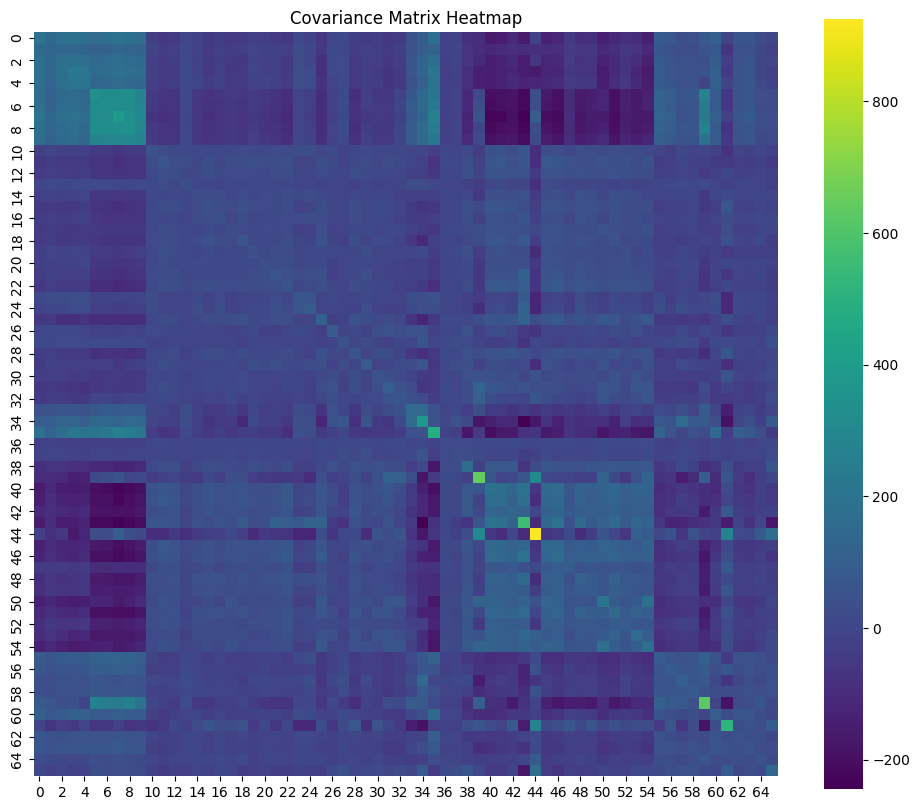

Shape of covariance matrix: (66, 66)

Maximum value: 924.4222735281026
Minimum value: -244.65203281373346
Mean value: 5.80700674771799e-16


In [198]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

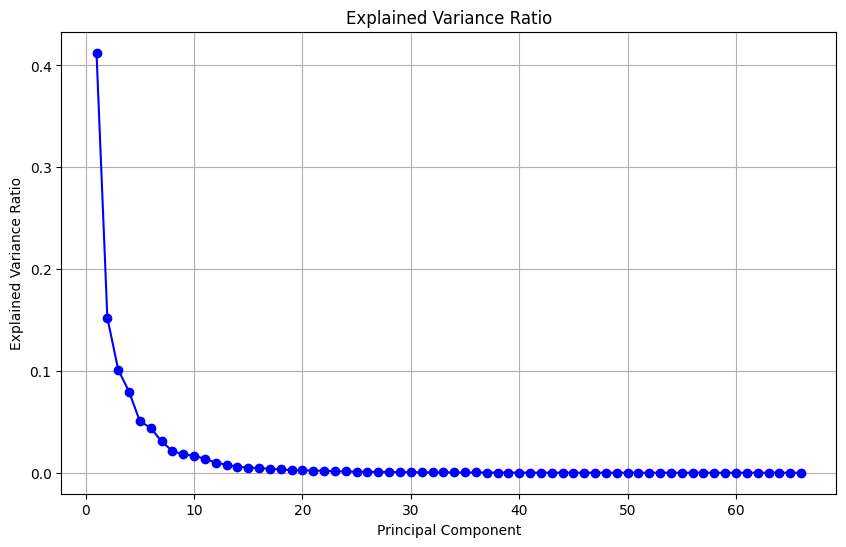

In [199]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [200]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.4124
PC2: 0.5647
PC3: 0.6660
PC4: 0.7456
PC5: 0.7962
PC6: 0.8402
PC7: 0.8710
PC8: 0.8923
PC9: 0.9103
PC10: 0.9269
PC11: 0.9407
PC12: 0.9504
PC13: 0.9583
PC14: 0.9641
PC15: 0.9691
PC16: 0.9738
PC17: 0.9776
PC18: 0.9809
PC19: 0.9833
PC20: 0.9856
PC21: 0.9877
PC22: 0.9896
PC23: 0.9911
PC24: 0.9923
PC25: 0.9933
PC26: 0.9942
PC27: 0.9951
PC28: 0.9958
PC29: 0.9965
PC30: 0.9970
PC31: 0.9975
PC32: 0.9979
PC33: 0.9982
PC34: 0.9985
PC35: 0.9987
PC36: 0.9989
PC37: 0.9991
PC38: 0.9993
PC39: 0.9994
PC40: 0.9995
PC41: 0.9996
PC42: 0.9997
PC43: 0.9997
PC44: 0.9998
PC45: 0.9998
PC46: 0.9998
PC47: 0.9999
PC48: 0.9999
PC49: 0.9999
PC50: 0.9999
PC51: 0.9999
PC52: 0.9999
PC53: 1.0000
PC54: 1.0000
PC55: 1.0000
PC56: 1.0000
PC57: 1.0000
PC58: 1.0000
PC59: 1.0000
PC60: 1.0000
PC61: 1.0000
PC62: 1.0000
PC63: 1.0000
PC64: 1.0000
PC65: 1.0000
PC66: 1.0000


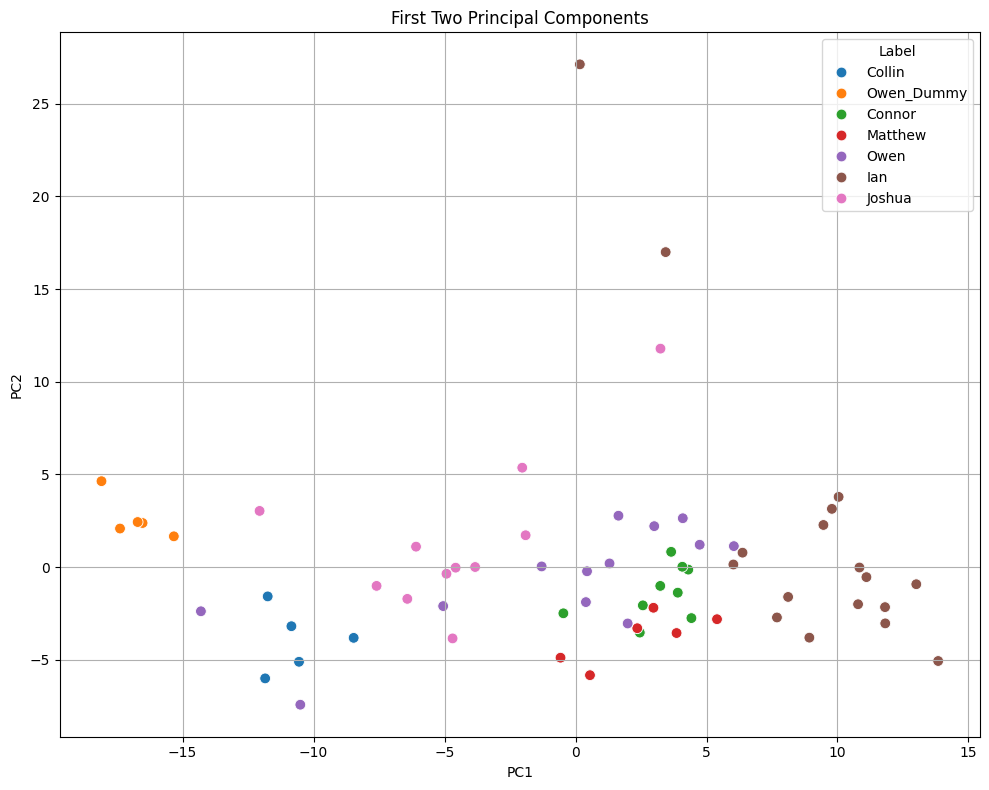

In [201]:
# Plot the first two principal components
labels = merged_df["label"]
pca_df = pd.DataFrame({
    'PC1': scores[:, 0],
    'PC2': scores[:, 1],
    'Label': labels  # categorical labels, e.g., 'annie', 'bob'
})

# Plot with seaborn: hue assigns color by label
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='tab10', s=60)

plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()

Look at the loadings

In [206]:
s

array([6.75097503e+01, 4.10191437e+01, 3.34546210e+01, 2.96631493e+01,
       2.36368319e+01, 2.20521463e+01, 1.84343934e+01, 1.53433143e+01,
       1.41071632e+01, 1.35373673e+01, 1.23458109e+01, 1.04034890e+01,
       9.34262604e+00, 8.00913897e+00, 7.41171590e+00, 7.18968850e+00,
       6.47882491e+00, 6.01306615e+00, 5.20117305e+00, 5.02662250e+00,
       4.83230699e+00, 4.58642485e+00, 3.99904349e+00, 3.73834940e+00,
       3.30919603e+00, 3.13138813e+00, 3.04595603e+00, 2.90219310e+00,
       2.68779503e+00, 2.52287692e+00, 2.15783389e+00, 2.06793238e+00,
       1.90211305e+00, 1.78788035e+00, 1.60445721e+00, 1.58323766e+00,
       1.53661689e+00, 1.33473714e+00, 1.09616238e+00, 1.00662430e+00,
       9.24960506e-01, 8.76583692e-01, 8.00754728e-01, 7.49906095e-01,
       6.68064526e-01, 6.51022432e-01, 5.58391319e-01, 4.96455387e-01,
       4.60995147e-01, 4.43575618e-01, 3.79201438e-01, 3.56084502e-01,
       3.36416140e-01, 3.11391030e-01, 2.53819616e-01, 2.39620158e-01,
      

In [202]:
loadings = pd.DataFrame(Vt.T)

# ——— Loop to pull out max index & value per column ———
for col in loadings.columns:
    max_idx = loadings[col].idxmax()   # label of the row with the max
    max_val = loadings[col].max()      # the max value itself
    min_idx = loadings[col].idxmin()   # label of the row with the max
    min_val = loadings[col].min()      # the max value itself
    print(f"Column '{col}': max = {max_val} at index '{max_idx}'")
    print(f"Column '{col}': min = {min_val} at index '{min_idx}'")
    print("\n")

Column '0': max = 0.10031188607527076 at index '58'
Column '0': min = -0.06223327293227628 at index '79'


Column '1': max = 0.15063474869068483 at index '91'
Column '1': min = -0.0989094740150493 at index '47'


Column '2': max = 0.1178923296274179 at index '127'
Column '2': min = -0.12923465225115427 at index '73'


Column '3': max = 0.11808687811244721 at index '101'
Column '3': min = -0.16653644634188064 at index '151'


Column '4': max = 0.12394791242378476 at index '69'
Column '4': min = -0.21261226930453467 at index '85'


Column '5': max = 0.15858990891855185 at index '132'
Column '5': min = -0.15805939596408358 at index '102'


Column '6': max = 0.21403524617299566 at index '96'
Column '6': min = -0.16608983858023355 at index '68'


Column '7': max = 0.1765165669967423 at index '104'
Column '7': min = -0.2537757209360078 at index '53'


Column '8': max = 0.13794951890900128 at index '51'
Column '8': min = -0.19149033257443776 at index '141'


Column '9': max = 0.15672024150211